In [10]:
#Import of all necessary packages
import pandas
import sklearn
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import auc, accuracy_score, precision_score, confusion_matrix, precision_recall_curve
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [11]:
# Import data and split it into two sets: features and the binary target (fraud or non-fraud transaction)
data = pandas.read_csv("creditcard.csv")
data = data.dropna()
x = data.iloc[:, :-1]
y = data.iloc[:,-1]

# Split the raw data into a training and testing set i.e. 70% to 30%
# Then scale the data using RobustScaler since features are PCA components
scaler = RobustScaler()
train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.30, random_state=42, stratify=y)
train_x = scaler.fit_transform(train_x)
test_x = scaler.transform(test_x)

# Split the training set into a final training and validation set i.e. 70% to 30%
input_dim = train_x.shape[1]
x_train, x_val, y_train, y_val = train_test_split(train_x, train_y, test_size=0.30, random_state=42, stratify=train_y)

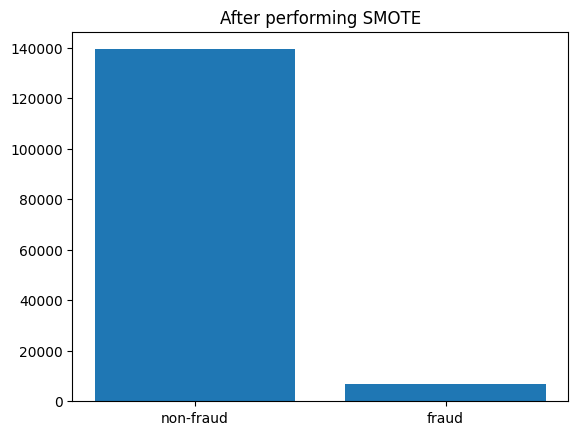

In [12]:
# Perform the constrained SMOTE approach using k = 3 
sm = SMOTE(random_state=42, k_neighbors=3, sampling_strategy=0.05)
x_train, y_train = sm.fit_resample(x_train, y_train)

# Graph after performing SMOTE
counts = y_train.value_counts()
plt.bar(['non-fraud', 'fraud'], counts.values)
plt.title("After performing SMOTE")
plt.show()

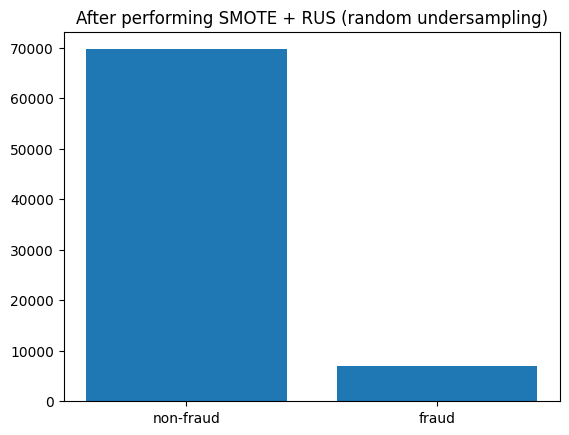

In [13]:
# Perform random undersampling to complete hybrid approach 
rm = RandomUnderSampler(random_state=42, sampling_strategy=0.1)
x_train, y_train = rm.fit_resample(x_train,y_train)

# Graph after performing SMOTE + RUS
counts = y_train.value_counts()
plt.bar(['non-fraud', 'fraud'], counts.values)
plt.title("After performing SMOTE + RUS (random undersampling)")
plt.show()

In [14]:
# Experiment to determine optimal batch size
batch_sizes = [64,128,256]

# (Epochs can be reduced to monitor baseline comparison)
for _ in range(10):
    for batch_sz in batch_sizes:
        # Implementation of the neural network 
        model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        tf.keras.layers.Dense(1, activation='sigmoid')
        ])

        # Compilation and training of the neural network (using current iteration batch size)
        model.compile(optimizer='adam', loss=tf.keras.losses.BinaryFocalCrossentropy(alpha=0.75, gamma=2.0), metrics=['precision'])
        model.fit(x = x_train, y=y_train, batch_size=batch_sz, epochs=10, validation_data=(x_val, y_val), verbose=0)
        
        # AUPRC performance metric
        scores_y = model.predict(test_x)
        precision, recall, thresholds = precision_recall_curve(test_y, scores_y)
        auprc = auc(recall, precision)

        print("AUC under PRC (Precision Recall Curve): ", auprc)

        # Plot of the PRC i.e. Precision Recall Curve graph 
        '''
        y_scores = model.predict(test_x)
        precision,recall, thresholds = sklearn.metrics.precision_recall_curve(test_y, y_scores)
        auprc = sklearn.metrics.auc(recall, precision)

        plt.plot(recall, precision, color='darkblue')
        plt.title('Precision Recall Curve')
        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.grid(True)
        plt.show()
        '''       
    
    print()

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 1s 177us/step
AUC under PRC (Precision Recall Curve):  0.7591482693235047
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 1s 220us/step
AUC under PRC (Precision Recall Curve):  0.7757505218025432
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 1s 196us/step
AUC under PRC (Precision Recall Curve):  0.7879069022813011

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 1s 179us/step
AUC under PRC (Precision Recall Curve):  0.7576610807427853
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 0s 176us/step
AUC under PRC (Precision Recall Curve):  0.766440262605453
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 0s 176us/step
AUC under PRC (Precision Recall Curve):  0.7325453237030632

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 0s 178us/step
AUC under PRC (Precision Recall Curve):  0.754072013715559
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 0s 178us/step
AUC under PRC (Precision Recall Curve):  0.7597960083487328
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 0s 177us/step
AUC under PRC (Precision Recall Curve):  0.7740518693341041

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 1s 180us/step
AUC under

In [15]:
# Experiment to determine optimal number of layers 

# Test model 1
modelt1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(1, activation='sigmoid')
    ])

modelt1.compile(optimizer='adam', loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, alpha=0.75), metrics=['precision'])
modelt1.fit(x = x_train, y=y_train, batch_size=256, epochs=10, validation_data=(x_val, y_val), verbose=0)

# AUPRC performance metric
scores_y = modelt1.predict(test_x)
precision, recall, _ = precision_recall_curve(test_y, scores_y)
auprc = auc(recall, precision)

print("AUC under PRC (Precision Recall Curve): ", auprc)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 1s 187us/step
AUC under PRC (Precision Recall Curve):  0.7348552132039256


In [16]:
# Test model 2
modelt2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(1, activation='sigmoid')
    ])

modelt2.compile(optimizer='adam', loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, alpha=0.75), metrics=['precision'])
modelt2.fit(x = x_train, y=y_train, batch_size=256, epochs=10, validation_data=(x_val, y_val), verbose=0)
    
# AUPRC performance metric
scores_y = modelt2.predict(test_x)
precision, recall, _ = precision_recall_curve(test_y, scores_y)
auprc = auc(recall, precision)

print("AUC under PRC (Precision Recall Curve): ", auprc)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 0s 171us/step
AUC under PRC (Precision Recall Curve):  0.7477597445846411


In [17]:
# Test model 3
modelt3 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(1, activation='sigmoid')
    ])

modelt3.compile(optimizer='adam', loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2.0, alpha=0.75), metrics=['precision'])
modelt3.fit(x = x_train, y=y_train, batch_size=256, epochs=10, validation_data=(x_val, y_val), verbose=0)
    
# AUPRC performance metric
scores_y = modelt3.predict(test_x)
precision, recall, _ = precision_recall_curve(test_y, scores_y)
auprc = auc(recall, precision)

print("AUC under PRC (Precision Recall Curve): ", auprc)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 1s 183us/step
AUC under PRC (Precision Recall Curve):  0.7624734501187852


In [23]:
# Implementation of final selected model 
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss=tf.keras.losses.BinaryFocalCrossentropy(gamma=2, alpha=0.75))
model.fit(x = x_train, y=y_train, batch_size=256, epochs=10, validation_data=(x_val, y_val), verbose=0)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 1s 180us/step


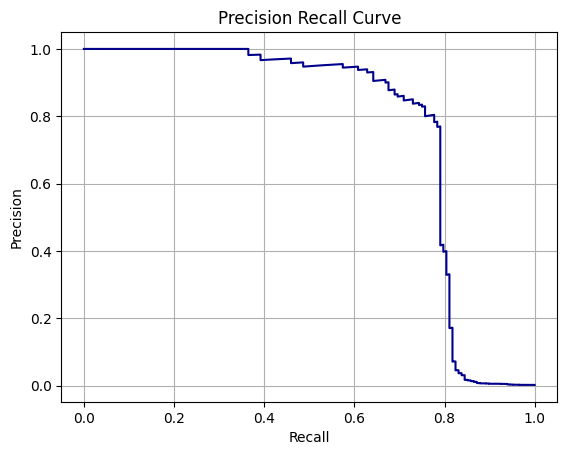

Optimal Threshold: 0.7459
Accuracy: 0.9993
Precision: 0.8296
False Positive Rate: 0.0003
AUPRC: 0.7674
Fraud Amount Recovered: 12,537.81
Total Fraud Amount: 19,311.89
Financial Recovery: 0.65


In [24]:
# Plot of the PRC (Precision Recall Curve)
y_scores = model.predict(test_x)
precision,recall, thresholds = sklearn.metrics.precision_recall_curve(test_y, y_scores)
auprc = sklearn.metrics.auc(recall, precision)

plt.plot(recall, precision, color='darkblue')
plt.title('Precision Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True)
plt.show()

# Compute and store the optimal threshold
f1_scores = 2*(precision[:-1]*recall[:-1])/(precision[:-1]+recall[:-1])

idx = np.argmax(f1_scores)
optimal_threshold = thresholds[idx]

# Display the standard metrics 
pred_y = (y_scores >= optimal_threshold).astype(int)
acc = accuracy_score(test_y, pred_y)
pres = precision_score(test_y, pred_y)

tn, fp, fn, tp = confusion_matrix(test_y, pred_y, labels=[0, 1]).ravel()
fpr = fp / (fp + tn)

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {pres:.4f}")  
print(f"False Positive Rate: {fpr:.4f}")
print(f"AUPRC: {auprc:.4f}")

# Conversion to numpy array
y_true = test_y.values.flatten()

# Calculate the fraudulent and recovered fraudulent money
recov_money = data.loc[test_y.index[(y_true.flatten() == 1) & (pred_y.flatten() == 1)], 'Amount'].sum()
fraud_money = data.loc[test_y.index[(y_true.flatten() == 1)], 'Amount'].sum()

# Metric calculation
financial_recovery = recov_money / fraud_money

# Metric display
print(f"Fraud Amount Recovered: {recov_money:,.2f}")
print(f"Total Fraud Amount: {fraud_money:,.2f}")

print(f"Financial Recovery: {financial_recovery:.2}")